# Extract 2D cluster-correction vote maps

Reads `Make2DClusterCorrectionVotes_v3.C` output, finds the most-voted $(\Delta r, r\Delta\phi)$ point in every side/charge/$p_T$/module/$\phi$-bin/layer-bin histogram, optionally fills missing bins, and writes ROOT maps.

In [1]:
import ROOT as root
import math
from pathlib import Path

root.gROOT.SetBatch(True)

input_file  = Path('input/pp_test2.root')
output_file = Path('cluster_2d_correction_map.root')

do_interpolate = False
do_extrapolate = False
save_output = True

peak_radius_bins = 2      # centroid around the maximum bin
min_peak_entries = 2.0   # minimum integral in one vote histogram
min_peak_fraction = 0.0000002  # maximum-bin content / histogram integral

pt_bins = [
    'pt_0p2_0p4', 'pt_0p4_0p7', 'pt_0p7_1p2'
]
sides = ['side0', 'side1']
charges = ['qminus', 'qplus']


Welcome to JupyROOT 6.30/06


In [2]:
def weighted_peak_2d(hist, radius_bins=2):
    """Return the weighted centroid around the global maximum."""

    total = hist.Integral()

    if total < min_peak_entries:
        return None

    max_bin = hist.GetMaximumBin()

    nx = hist.GetNbinsX() + 2
    ny = hist.GetNbinsY() + 2

    ix = max_bin % nx
    iy = (max_bin // nx) % ny

    if ix < 1 or ix > hist.GetNbinsX():
        return None

    if iy < 1 or iy > hist.GetNbinsY():
        return None

    peak = hist.GetBinContent(ix, iy)

    if peak / total < min_peak_fraction:
        return None

    bx_min = max(1, ix - radius_bins)
    bx_max = min(hist.GetNbinsX(), ix + radius_bins)

    by_min = max(1, iy - radius_bins)
    by_max = min(hist.GetNbinsY(), iy + radius_bins)

    sx = 0.0
    sy = 0.0
    sw = 0.0

    for bx in range(bx_min, bx_max + 1):
        for by in range(by_min, by_max + 1):

            weight = hist.GetBinContent(bx, by)

            if weight <= 0:
                continue

            delta_r = hist.GetXaxis().GetBinCenter(bx)
            delta_rphi = hist.GetYaxis().GetBinCenter(by)

            sx += weight * delta_r
            sy += weight * delta_rphi
            sw += weight

    if sw <= 0:
        return None

    delta_r = sx / sw
    delta_rphi = sy / sw

    variance_r = 0.0
    variance_rphi = 0.0

    for bx in range(bx_min, bx_max + 1):
        for by in range(by_min, by_max + 1):

            weight = hist.GetBinContent(bx, by)

            if weight <= 0:
                continue

            x = hist.GetXaxis().GetBinCenter(bx)
            y = hist.GetYaxis().GetBinCenter(by)

            variance_r += weight * (x - delta_r) ** 2
            variance_rphi += weight * (y - delta_rphi) ** 2

    return {
        "dr": delta_r,
        "drphi": delta_rphi,
        "sigma_dr": math.sqrt(variance_r / sw),
        "sigma_drphi": math.sqrt(variance_rphi / sw),
        "entries": total,
        "peak_fraction": peak / total,
    }

def get_hist(root_file, side, charge, pt_bin, module, phi_bin, layer_bin):
    path = (
        f'{side}/{charge}/{pt_bin}/module_{module:02d}/'
        f'phi_{phi_bin}_layer_{layer_bin}/h_deltaRPhi_vs_deltaR_votes'
    )
    return root_file.Get(path)


In [3]:
f = root.TFile.Open(str(input_file), 'READ')
if not f or f.IsZombie():
    raise OSError(f'Cannot open {input_file}')

points = {}

for side in sides:
    for charge in charges:
        for pt_bin in pt_bins:
            for module in range(36):
                for phi_bin in range(3):
                    for layer_bin in range(5):
                        h = get_hist(f, side, charge, pt_bin, module, phi_bin, layer_bin)
                        key = (side, charge, pt_bin, module, phi_bin, layer_bin)
                        points[key] = weighted_peak_2d(h, peak_radius_bins) if h else None

n_good = sum(value is not None for value in points.values())
print(f'Found peaks in {n_good} / {len(points)} bins')


Found peaks in 6353 / 6480 bins


In [4]:
def neighbor_values(key, field):
    side, charge, pt_bin, module, phi_bin, layer_bin = key
    values = []

    # Only neighbors inside the same hardware module and category.
    for dphi, dlayer in [(-1,0), (1,0), (0,-1), (0,1)]:
        p = phi_bin + dphi
        l = layer_bin + dlayer
        if 0 <= p < 3 and 0 <= l < 5:
            neighbor = points.get((side, charge, pt_bin, module, p, l))
            if neighbor is not None:
                values.append(neighbor[field])
    return values


def fill_missing_points():
    if not do_interpolate and not do_extrapolate:
        return

    updates = {}
    for key, value in points.items():
        if value is not None:
            continue

        dr_values = neighbor_values(key, 'dr')
        dp_values = neighbor_values(key, 'drphi')

        enough = len(dr_values) >= 2 if do_interpolate else len(dr_values) >= 1
        if not enough:
            continue

        updates[key] = {
            'dr': sum(dr_values)/len(dr_values),
            'drphi': sum(dp_values)/len(dp_values),
            'sigma_dr': 0.0,
            'sigma_drphi': 0.0,
            'entries': 0.0,
            'peak_fraction': 0.0,
            'filled': True,
        }

    points.update(updates)
    print(f'Filled {len(updates)} missing bins')


fill_missing_points()


In [5]:
def make_map(name, title):
    h = root.TH2D(name, title, 3, -0.5, 2.5, 5, -0.5, 4.5)
    h.SetDirectory(0)
    h.GetXaxis().SetTitle('local #phi bin')
    h.GetYaxis().SetTitle('local layer bin')
    return h

if save_output:
    out = root.TFile.Open(str(output_file), 'RECREATE')
    if not out or out.IsZombie():
        raise OSError(f'Cannot create {output_file}')
    
    for side in sides:
        for charge in charges:
            for pt_bin in pt_bins:
                for module in range(36):
                    path = f'{side}/{charge}/{pt_bin}/module_{module:02d}'
                    directory = out
                    for token in path.split('/'):
                        directory = directory.GetDirectory(token) or directory.mkdir(token)
                    directory.cd()
    
                    h_dr = make_map('h_deltaR_map', '#Delta r correction map;local #phi bin;local layer bin')
                    h_dp = make_map('h_deltaRPhi_map', 'r#Delta#phi correction map;local #phi bin;local layer bin')
                    h_n  = make_map('h_entries_map', 'Vote histogram integral;local #phi bin;local layer bin')
                    h_q  = make_map('h_peakFraction_map', 'Peak fraction;local #phi bin;local layer bin')
                    h_ok = make_map('h_valid_map', 'Valid correction bin;local #phi bin;local layer bin')
    
                    for phi_bin in range(3):
                        for layer_bin in range(5):
                            key = (side, charge, pt_bin, module, phi_bin, layer_bin)
                            value = points[key]
                            bx, by = phi_bin + 1, layer_bin + 1
                            if value is None:
                                continue
                            
                            h_dr.SetBinContent(bx, by, value['dr'])
                            h_dp.SetBinContent(bx, by, value['drphi'])
                            h_n.SetBinContent(bx, by, value['entries'])
                            h_q.SetBinContent(bx, by, value['peak_fraction'])
                            h_ok.SetBinContent(bx, by, 1.0)
                            h_dr.SetBinError(bx, by, value['sigma_dr'])
                            h_dp.SetBinError(bx, by, value['sigma_drphi'])
    
                    for h in [h_dr, h_dp, h_n, h_q, h_ok]:
                        h.Write()
    
    out.Close()
    f.Close()
    print(f'Wrote correction maps to {output_file}')
    

Wrote correction maps to cluster_2d_correction_map.root


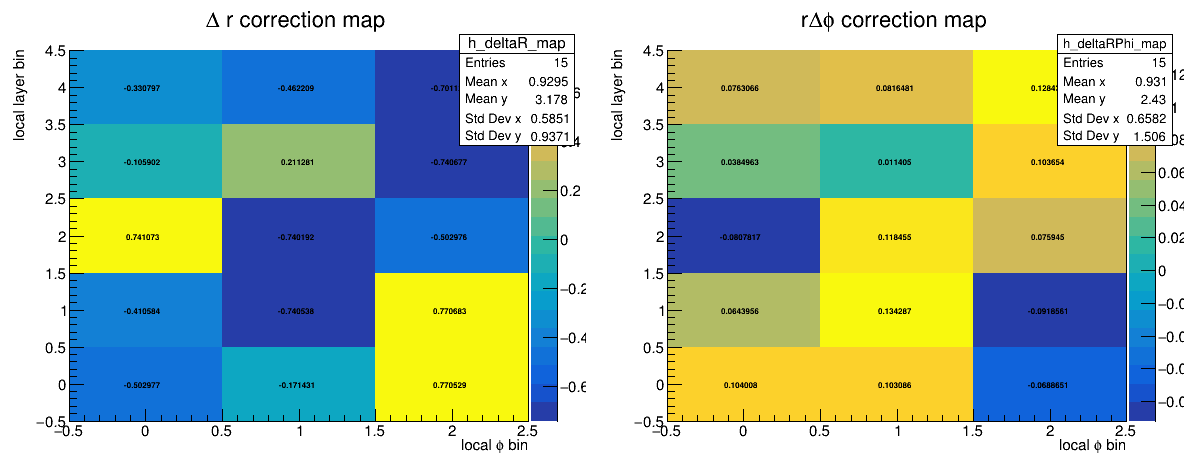

In [6]:
# Compact inspection example
check = root.TFile.Open(str(output_file))
path = 'side0/qplus/pt_0p7_1p2/module_10'

c = root.TCanvas('c_map', 'c_map', 1200, 500)
c.Divide(2, 1)

c.cd(1)
h1 = check.Get(f'{path}/h_deltaR_map')
h1.Draw('COLZ TEXT')

c.cd(2)
h2 = check.Get(f'{path}/h_deltaRPhi_map')
h2.Draw('COLZ TEXT')

c.Draw()
